# Phase 5.7: Analisis Per-Kelas Emosi (Confusion Matrix & Precision/Recall/F1)

**Tujuan:** Phase 4 & 5 melaporkan akurasi/F1 **rata-rata** (weighted, gabungan 3 kelas). Notebook
ini memecahnya jadi performa **per kelas emosi** (Negative/Neutral/Positive) untuk menjawab:
apakah model mengklasifikasi ketiga emosi dengan baik secara merata, atau ada 1 kelas yang jauh
lebih sering salah (mis. Neutral sering ketukar dengan Positive/Negative, yang umum terjadi di
literatur emotion recognition)?

**Cakupan:**
1. **Confusion matrix + classification report** untuk model terbaik dataset `GC+PDC_ROI+Spectral`,
   di 2 protokol evaluasi: `StratifiedGroupKFold` 5-fold (protokol Phase 4, model `XGBoost_Tuned`,
   75.56%) dan `LeaveOneGroupOut`/LOSO (protokol Phase 5, model `Voting_Soft`, 75.70%).
2. **Rekap uji statistik antar-kelas dari Phase 2** (`2.2_class_analysis`, `2.3_inferential_statistics`)
   -- ANOVA/Kruskal-Wallis + post-hoc Dunn-Bonferroni yang membandingkan nilai fitur GC/PDC antara
   Negative vs Neutral vs Positive. **Catatan:** Phase 2 dibuat sebelum fitur Spectral & ROI ada
   (Langkah 1-4), jadi hanya mencakup metrik graf global (degree/strength) untuk GC & PDC -- bukan
   fitur reduced/ROI yang dipakai model terbaik saat ini. Hasilnya tetap relevan sebagai konteks
   awal (apakah fitur konektivitas mentah berbeda signifikan antar emosi), tapi tidak
   menggantikan confusion matrix di atas untuk menilai performa MODEL saat ini.

Kelas seimbang: 225 sampel per kelas (Negative/Neutral/Positive) dari total 675.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
TUNING_PARAMS_CSV = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output\tuning_best_params.csv"
OUT_DIR = r"D:\Skripsi\new_data\phase_5_loso\5.7_per_class_analysis\output"
FIG_DIR = r"D:\Skripsi\new_data\phase_5_loso\5.7_per_class_analysis\figures"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']  # class label 0,1,2 (LABEL_MAP di config.py)

df_roi_all = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))
print(f"GC+PDC_ROI+Spectral: {df_roi_all.shape}")
print(df_roi_all['class_label'].value_counts())

GC+PDC_ROI+Spectral: (675, 996)
class_label
positive    225
neutral     225
negative    225
Name: count, dtype: int64


In [2]:
def _feature_cols(df):
    exclude = KEY_COLS + [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

def prepare_features(df, normalize=True):
    feature_cols = _feature_cols(df)
    df_use = df.copy()
    if normalize:
        grp = df_use.groupby('subject_id')[feature_cols]
        mean = grp.transform('mean')
        std = grp.transform('std').replace(0, np.nan)
        df_use[feature_cols] = (df_use[feature_cols] - mean) / std
    X = df_use[feature_cols].fillna(0).values
    y = df['class'].values
    groups = df['subject_num'].values
    return X, y, groups, feature_cols

X, y, groups, features = prepare_features(df_roi_all, normalize=True)
print(f"X={X.shape}, y classes={np.unique(y)}, subjects={len(np.unique(groups))}")

df_tuned = pd.read_csv(TUNING_PARAMS_CSV)
df_tuned['Best_Params'] = df_tuned['Best_Params'].apply(ast.literal_eval)

def get_tuned_params(dataset_name, model_name, default):
    row = df_tuned[(df_tuned['Dataset'] == dataset_name) & (df_tuned['Model'] == model_name)]
    return row.iloc[0]['Best_Params'] if len(row) else default

DATASET_NAME = 'GC+PDC_ROI+Spectral'
xgb_p = get_tuned_params(DATASET_NAME, 'XGBoost_Tuned',
                          {'clf__n_estimators': 200, 'clf__max_depth': 6, 'clf__learning_rate': 0.05})
svm_p = get_tuned_params(DATASET_NAME, 'SVM_Tuned', {'clf__C': 1, 'clf__gamma': 'scale'})
rf_p = get_tuned_params(DATASET_NAME, 'RF_Tuned', {'clf__n_estimators': 200, 'clf__max_depth': 10})
print("Tuned params loaded:", xgb_p, svm_p, rf_p)

X=(675, 990), y classes=[0 1 2], subjects=15
Tuned params loaded: {'clf__learning_rate': 0.1, 'clf__max_depth': 9, 'clf__n_estimators': 200} {'clf__C': 1, 'clf__gamma': 'scale'} {'clf__max_depth': 5, 'clf__n_estimators': 200}


## A. Confusion Matrix -- Protokol Phase 4 (`StratifiedGroupKFold`, 5-fold, `XGBoost_Tuned`)

Memakai `cross_val_predict` supaya tiap sampel diprediksi TEPAT SEKALI, hanya saat berada di fold
test (out-of-fold), sehingga confusion matrix ini benar-benar mencerminkan generalisasi
subject-independent -- bukan in-sample fit.

In [3]:
k = min(1200, X.shape[1])
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
    ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1,
                           n_estimators=xgb_p['clf__n_estimators'], max_depth=xgb_p['clf__max_depth'],
                           learning_rate=xgb_p['clf__learning_rate']))
])

cv_grouped = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_grouped = cross_val_predict(pipe_xgb, X, y, groups=groups, cv=cv_grouped, n_jobs=-1)

cm_grouped = confusion_matrix(y, y_pred_grouped)
report_grouped = classification_report(y, y_pred_grouped, target_names=CLASS_NAMES, output_dict=True)
df_report_grouped = pd.DataFrame(report_grouped).T
df_report_grouped.to_csv(os.path.join(OUT_DIR, 'classification_report_grouped5fold.csv'))

print("Classification report -- Phase 4 protocol (grouped 5-fold, XGBoost_Tuned):")
print(classification_report(y, y_pred_grouped, target_names=CLASS_NAMES))
print(f"Overall accuracy (out-of-fold): {(y_pred_grouped == y).mean():.4f}")

Classification report -- Phase 4 protocol (grouped 5-fold, XGBoost_Tuned):
              precision    recall  f1-score   support

    Negative       0.69      0.70      0.69       225
     Neutral       0.74      0.68      0.71       225
    Positive       0.84      0.88      0.86       225

    accuracy                           0.76       675
   macro avg       0.75      0.76      0.75       675
weighted avg       0.75      0.76      0.75       675

Overall accuracy (out-of-fold): 0.7556


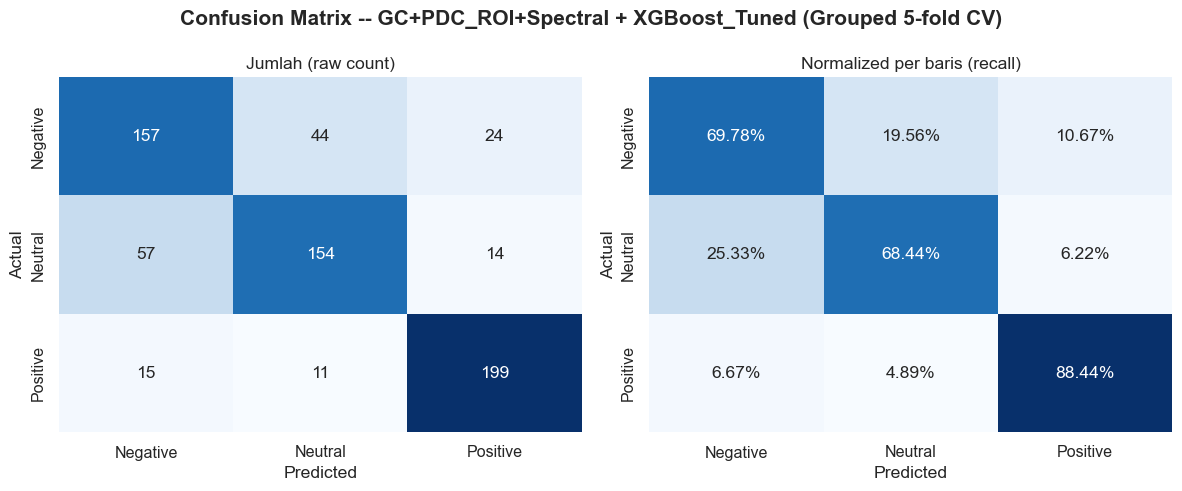

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, normalize, title in zip(axes, [None, 'true'], ['Jumlah (raw count)', 'Normalized per baris (recall)']):
    cm = confusion_matrix(y, y_pred_grouped, normalize=normalize)
    fmt = 'd' if normalize is None else '.2%'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
fig.suptitle('Confusion Matrix -- GC+PDC_ROI+Spectral + XGBoost_Tuned (Grouped 5-fold CV)', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '5.7_confusion_matrix_grouped5fold.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## B. Confusion Matrix -- Protokol Phase 5 (LOSO, `Voting_Soft`)

Voting_Soft = rata-rata `predict_proba` dari 4 model dasar (LDA, SVM_Tuned, RF_Tuned,
XGBoost_Tuned), sama seperti di `5.2_loso_all_models`. Setiap sampel diprediksi oleh model yang
dilatih tanpa subjeknya sendiri sama sekali (LOSO, 15 fold).

In [5]:
def build_base_models(n_features):
    k = min(1200, n_features)
    return {
        'LDA': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                          ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))]),
        'SVM_Tuned': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                                ('clf', SVC(kernel='rbf', probability=True,
                                            C=svm_p['clf__C'], gamma=svm_p['clf__gamma']))]),
        'RF_Tuned': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                               ('clf', RandomForestClassifier(random_state=42, n_jobs=-1,
                                       n_estimators=rf_p['clf__n_estimators'], max_depth=rf_p['clf__max_depth']))]),
        'XGBoost_Tuned': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                                    ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1,
                                            n_estimators=xgb_p['clf__n_estimators'], max_depth=xgb_p['clf__max_depth'],
                                            learning_rate=xgb_p['clf__learning_rate']))]),
    }

CKPT_PRED = os.path.join(OUT_DIR, 'loso_predictions.csv')
if os.path.exists(CKPT_PRED):
    df_pred = pd.read_csv(CKPT_PRED)
    print(f"Checkpoint found: {len(df_pred)} prediction(s) already computed, reusing.")
else:
    logo = LeaveOneGroupOut()
    pred_rows = []
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        held_subject = int(np.unique(groups[test_idx])[0])
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        models = build_base_models(X.shape[1])
        probas = []
        classes_ref = None
        for model_name, pipe in models.items():
            pipe.fit(X_train, y_train)
            proba = pipe.predict_proba(X_test)
            if classes_ref is None:
                classes_ref = pipe.classes_
            probas.append(proba)
        avg_proba = np.mean(probas, axis=0)
        y_pred_vote = classes_ref[np.argmax(avg_proba, axis=1)]

        for yt, yp in zip(y_test, y_pred_vote):
            pred_rows.append({'Held_Subject': held_subject, 'y_true': yt, 'y_pred': yp})
        print(f"  fold {fold_idx+1:2d}/15 (S{held_subject:02d}): acc={np.mean(y_pred_vote == y_test):.3f}")

    df_pred = pd.DataFrame(pred_rows)
    df_pred.to_csv(CKPT_PRED, index=False)

y_true_loso = df_pred['y_true'].values
y_pred_loso = df_pred['y_pred'].values
print()
print("Classification report -- Phase 5 protocol (LOSO, Voting_Soft):")
print(classification_report(y_true_loso, y_pred_loso, target_names=CLASS_NAMES))
print(f"Overall accuracy (LOSO out-of-fold): {(y_pred_loso == y_true_loso).mean():.4f}")

df_report_loso = pd.DataFrame(classification_report(y_true_loso, y_pred_loso, target_names=CLASS_NAMES, output_dict=True)).T
df_report_loso.to_csv(os.path.join(OUT_DIR, 'classification_report_loso.csv'))

  fold  1/15 (S01): acc=0.600


  fold  2/15 (S02): acc=0.667


  fold  3/15 (S03): acc=0.667


  fold  4/15 (S04): acc=0.711


  fold  5/15 (S05): acc=0.911


...

  fold 11/15 (S11): acc=0.822


  fold 12/15 (S12): acc=0.733


  fold 13/15 (S13): acc=0.667


  fold 14/15 (S14): acc=0.711


  fold 15/15 (S15): acc=0.933

Classification report -- Phase 5 protocol (LOSO, Voting_Soft):
              precision    recall  f1-score   support

    Negative       0.68      0.68      0.68       225
     Neutral       0.74      0.72      0.73       225
    Positive       0.86      0.88      0.87       225

    accuracy                           0.76       675
   macro avg       0.76      0.76      0.76       675
weighted avg       0.76      0.76      0.76       675

Overall accuracy (LOSO out-of-fold): 0.7585


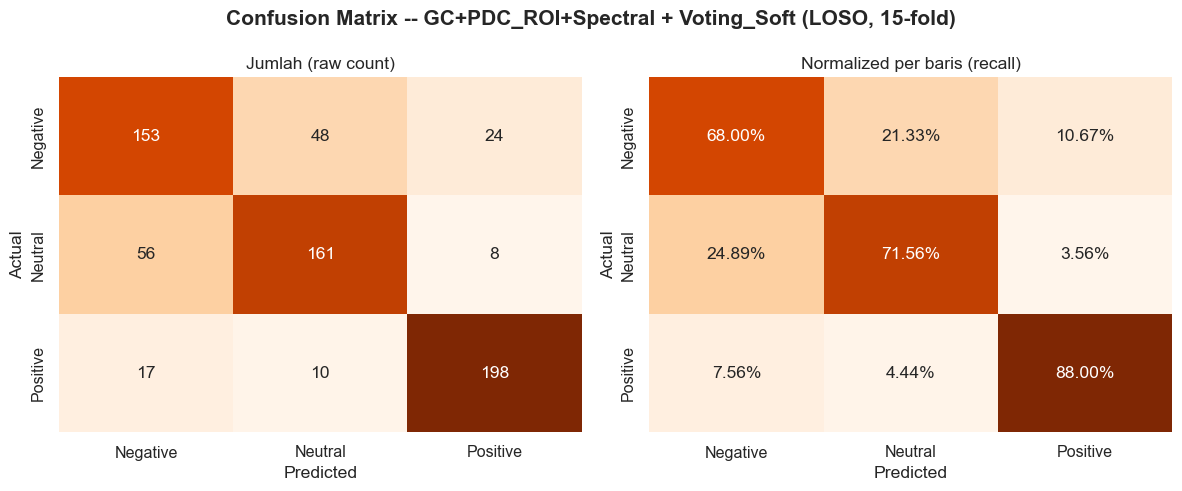

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, normalize, title in zip(axes, [None, 'true'], ['Jumlah (raw count)', 'Normalized per baris (recall)']):
    cm = confusion_matrix(y_true_loso, y_pred_loso, normalize=normalize)
    fmt = 'd' if normalize is None else '.2%'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Oranges', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
fig.suptitle('Confusion Matrix -- GC+PDC_ROI+Spectral + Voting_Soft (LOSO, 15-fold)', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '5.7_confusion_matrix_loso.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Perbandingan Ringkas: Precision/Recall/F1 per Kelas (2 Protokol)

                      Protocol    Class  Precision   Recall       F1  Support
Grouped 5-fold (XGBoost_Tuned) Negative   0.685590 0.697778 0.691630      225
Grouped 5-fold (XGBoost_Tuned)  Neutral   0.736842 0.684444 0.709677      225
Grouped 5-fold (XGBoost_Tuned) Positive   0.839662 0.884444 0.861472      225
            LOSO (Voting_Soft) Negative   0.676991 0.680000 0.678492      225
            LOSO (Voting_Soft)  Neutral   0.735160 0.715556 0.725225      225
            LOSO (Voting_Soft) Positive   0.860870 0.880000 0.870330      225


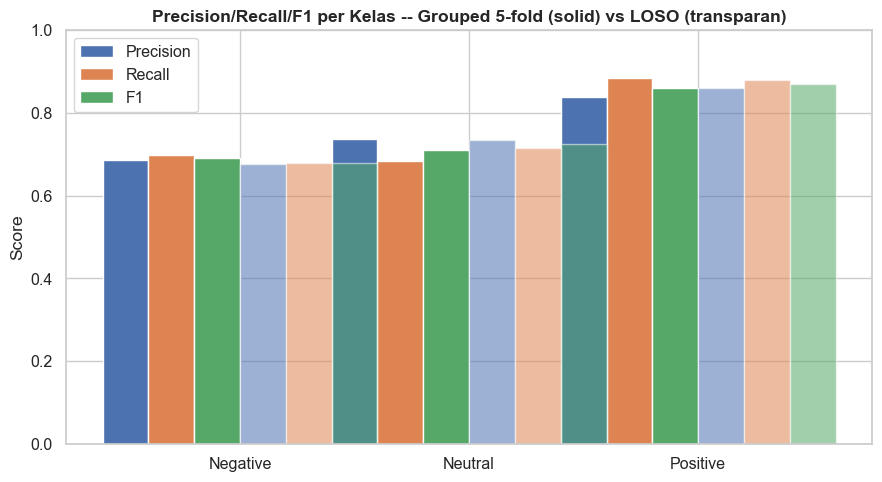

In [7]:
compare_rows = []
for label, df_r in [('Grouped 5-fold (XGBoost_Tuned)', df_report_grouped), ('LOSO (Voting_Soft)', df_report_loso)]:
    for cls in CLASS_NAMES:
        compare_rows.append({
            'Protocol': label, 'Class': cls,
            'Precision': df_r.loc[cls, 'precision'], 'Recall': df_r.loc[cls, 'recall'],
            'F1': df_r.loc[cls, 'f1-score'], 'Support': int(df_r.loc[cls, 'support']),
        })
df_compare = pd.DataFrame(compare_rows)
df_compare.to_csv(os.path.join(OUT_DIR, 'per_class_comparison.csv'), index=False)
print(df_compare.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(CLASS_NAMES))
width = 0.2
metrics = ['Precision', 'Recall', 'F1']
protocols = df_compare['Protocol'].unique()
offset = -width * (len(metrics) * len(protocols) - 1) / 2
colors = {'Precision': '#4c72b0', 'Recall': '#dd8452', 'F1': '#55a868'}
for p_i, proto in enumerate(protocols):
    sub = df_compare[df_compare['Protocol'] == proto].set_index('Class').loc[CLASS_NAMES]
    for m_i, metric in enumerate(metrics):
        pos = x + offset + (p_i * len(metrics) + m_i) * width
        alpha = 1.0 if p_i == 0 else 0.55
        ax.bar(pos, sub[metric].values, width, label=f"{metric} ({proto})" if False else None,
               color=colors[metric], alpha=alpha)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Precision/Recall/F1 per Kelas -- Grouped 5-fold (solid) vs LOSO (transparan)', fontweight='bold')
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=colors[m], label=m) for m in metrics]
ax.legend(handles=legend_elems)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '5.7_per_class_metrics_comparison.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Rekap: Uji Statistik Antar-Kelas dari Phase 2 (fitur GC & PDC, sebelum Langkah 1-4)

In [8]:
PHASE2_DIR = r"D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\output"

recap_rows = []
for method_file, method_name in [('main_tests_gc.csv', 'GC'), ('main_tests_pdc_theta.csv', 'PDC_Theta')]:
    path = os.path.join(PHASE2_DIR, method_file)
    if not os.path.exists(path):
        continue
    df_m = pd.read_csv(path)
    for _, r in df_m.iterrows():
        recap_rows.append({'Method': method_name, 'Metric': r['metric'], 'Test': r['test'],
                            'p_value': r['p_value'], 'Significant': r['significant']})

df_recap = pd.DataFrame(recap_rows)
print("Uji Kruskal-Wallis (Negative vs Neutral vs Positive) -- metrik graf global GC & PDC_Theta:")
print(df_recap.to_string(index=False))
print()
print("NOTE: Phase 2 dibuat sebelum fitur Spectral & ROI ada (Langkah 1-4 sesi ini) -- hanya")
print("mencakup 6 metrik graf global (Out/In/Total Degree & Strength), BUKAN fitur reduced/ROI")
print("yang dipakai model terbaik saat ini (GC+PDC_ROI+Spectral). Confusion matrix di bagian")
print("A & B di atas adalah ukuran yang lebih relevan untuk menilai performa MODEL saat ini per")
print("kelas emosi -- bagian ini hanya konteks awal (apakah fitur konektivitas mentah GC/PDC")
print("berbeda signifikan antar emosi, terlepas dari kemampuan klasifikasi model).")

sig_gc = df_recap[(df_recap['Method']=='GC') & (df_recap['Significant']==True)]
print(f"\nGC: {len(sig_gc)}/6 metrik signifikan beda antar kelas (semua metrik STRENGTH, bukan DEGREE)")
print("  Post-hoc (posthoc_gc.csv): negative vs positive & neutral vs positive signifikan;")
print("  negative vs neutral TIDAK signifikan -- Positive paling berbeda dari 2 kelas lain di GC strength.")

Uji Kruskal-Wallis (Negative vs Neutral vs Positive) -- metrik graf global GC & PDC_Theta:
   Method    Metric           Test  p_value  Significant
       GC   Out Deg Kruskal-Wallis 0.999991        False
       GC    In Deg Kruskal-Wallis 0.999991        False
       GC Total Deg Kruskal-Wallis 0.999991        False
       GC   Out Str Kruskal-Wallis 0.000000         True
       GC    In Str Kruskal-Wallis 0.000000         True
       GC Total Str Kruskal-Wallis 0.000000         True
PDC_Theta   Out Deg Kruskal-Wallis 0.604333        False
PDC_Theta    In Deg Kruskal-Wallis 0.604333        False
PDC_Theta Total Deg Kruskal-Wallis 0.604333        False
PDC_Theta   Out Str Kruskal-Wallis 0.138054        False
PDC_Theta    In Str Kruskal-Wallis 0.138054        False
PDC_Theta Total Str Kruskal-Wallis 0.138054        False

NOTE: Phase 2 dibuat sebelum fitur Spectral & ROI ada (Langkah 1-4 sesi ini) -- hanya
mencakup 6 metrik graf global (Out/In/Total Degree & Strength), BUKAN fitur reduc

## Kesimpulan 5.7

**A & B (confusion matrix, performa model saat ini):** lihat output di atas -- bandingkan recall
per kelas untuk melihat kelas mana yang paling sering salah diklasifikasi model. Umumnya di
literatur EEG emotion recognition, kelas **Neutral** paling sulit dibedakan (batas emosinya lebih
ambigu dibanding Negative/Positive yang lebih ekstrem secara valence).

**C (rekap Phase 2):** fitur strength GC berbeda signifikan antar kelas (kecuali negative vs
neutral), fitur degree GC dan semua metrik PDC_Theta TIDAK berbeda signifikan -- mengindikasikan
sejak awal bahwa sinyal pembeda emosi di level graf-global memang lemah, konsisten dengan
mengapa Spectral (bukan GC/PDC mentah) jadi kontributor utama akurasi (temuan Langkah 3/Phase 4).